# UFC Fighter Style Scout Using NMF

This project uses unsupervised learning to discover fighting-style archetypes from UFC athlete statistics.

Rather than predicting fight winners, the project examines how fighters operate:

- striking output;
- striking accuracy;
- damage absorbed;
- striking defence;
- takedown activity;
- takedown defence;
- submission activity;
- knockdown production.

Non-negative Matrix Factorisation separates these measurements into latent style components. Each fighter receives a mixture of the discovered components rather than one rigid style label.

The resulting representation is used to:

1. Interpret common UFC fighting archetypes.
2. Identify representative fighters for each archetype.
3. Find statistically similar fighters.
4. Compare the style profiles of two potential opponents.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import NMF, PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

SEED = 42
sns.set_theme(style="whitegrid")

## 1. Dataset

The athlete-level dataset contains physical information, career records and summarised UFC performance statistics.

The model focuses on rate and efficiency features rather than total career counts. Total counts would heavily separate long-career fighters from newer fighters instead of describing how they fight.

A minimum significant-strike-attempt threshold is applied because rate statistics calculated from very little UFC activity may be unreliable.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/rfordatascience/"
    "tidytuesday/main/data/2026/2026-07-07/ufc_athletes.csv"
)

raw_df = pd.read_csv(DATA_URL)

print("Raw shape:", raw_df.shape)
raw_df.head()

Raw shape: (3145, 43)


,name,nickname,weight_class,url,profile_name,profile_nickname,status,place_of_birth,age,height,...,clinch_count,clinch_percent,ground_count,ground_percent,ko_tko_win,ko_tko_percent,dec_wins,dec_percent,sub_wins,sub_percent
0,Danny Abbadi,The Assassin,Lightweight,https://www.ufc.com/athlete/danny-abbadi,Danny Abbadi,The Assassin,Not Fighting,"Orlando, United States",39.0,71.0,...,14.0,0.24,3.0,0.05,0.0,0.00,0.0,0.00,0.0,0.00
1,Nariman Abbassov,NaN,Lightweight,https://www.ufc.com/athlete/nariman-abbassov,Nariman Abbassov,NaN,Active,Kazakhstan,29.0,NaN,...,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00
2,Tank Abbott,Tank,Heavyweight,https://www.ufc.com/athlete/tank-abbott,Tank Abbott,Tank,Not Fighting,"Huntington Beach, United States",NaN,72.0,...,11.0,0.58,3.0,0.16,0.0,0.00,0.0,0.00,0.0,0.00
3,Hamdy Abdelwahab,The Hammer,Heavyweight,https://www.ufc.com/athlete/hamdy-abdelwahab,Hamdy Abdelwahab,The Hammer,Not Fighting,Egypt,32.0,74.0,...,15.0,0.06,100.0,0.39,5.0,0.71,2.0,0.29,0.0,0.00
4,Mansur Abdul-Malik,NaN,Middleweight,https://www.ufc.com/athlete/mansur-abdul-malik,Mansur Abdul-Malik,NaN,Active,"Pittsburgh, United States",28.0,74.0,...,16.0,0.11,66.0,0.44,7.0,0.78,0.0,0.00,2.0,0.22


In [3]:
model_features = [
    "sig_str_landed",
    "striking_accuracy",
    "sig_str_absorbed",
    "sig_str_defense",
    "takedown_avg",
    "takedown_defense",
    "submission_avg",
    "knockdown_avg"
]

source_numeric = [
    "sig_strikes_landed",
    "sig_strikes_attempted",
    "sig_str_landed",
    "sig_str_absorbed",
    "sig_str_defense",
    "takedown_avg",
    "takedown_defense",
    "submission_avg",
    "knockdown_avg",
    "standing_pct",
    "clinch_percent",
    "ground_percent"
]

In [4]:
df = raw_df.copy()

for column in source_numeric:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["striking_accuracy"] = np.where(
    df["sig_strikes_attempted"] > 0,
    df["sig_strikes_landed"] / df["sig_strikes_attempted"],
    np.nan
)

df["status"] = (
    df["status"]
    .astype(str)
    .str.replace('"', "", regex=False)
    .str.strip()
)

df["weight_class"] = df["weight_class"].fillna("Unknown")

MIN_STRIKE_ATTEMPTS = 100

fighter_df = (
    df.loc[df["sig_strikes_attempted"] >= MIN_STRIKE_ATTEMPTS]
    .dropna(subset=["name"] + model_features)
    .drop_duplicates(subset="name")
    .reset_index(drop=True)
)

print("Raw fighters:", raw_df["name"].nunique())
print("Eligible fighters:", len(fighter_df))
print("Minimum strike attempts:", MIN_STRIKE_ATTEMPTS)

Raw fighters: 3140
Eligible fighters: 2050
Minimum strike attempts: 100


In [5]:
audit = pd.DataFrame({
    "missing_before_filter": df[model_features].isna().sum(),
    "minimum": fighter_df[model_features].min(),
    "median": fighter_df[model_features].median(),
    "maximum": fighter_df[model_features].max()
})

audit.round(3)

,missing_before_filter,minimum,median,maximum
sig_str_landed,281,0.490,3.345,12.29
striking_accuracy,289,0.126,0.451,0.80
sig_str_absorbed,281,0.660,3.440,12.83
sig_str_defense,293,0.250,0.545,0.81
takedown_avg,281,0.000,1.140,14.00
takedown_defense,737,0.060,0.630,1.00
submission_avg,281,0.000,0.345,6.77
knockdown_avg,281,0.000,0.200,5.04


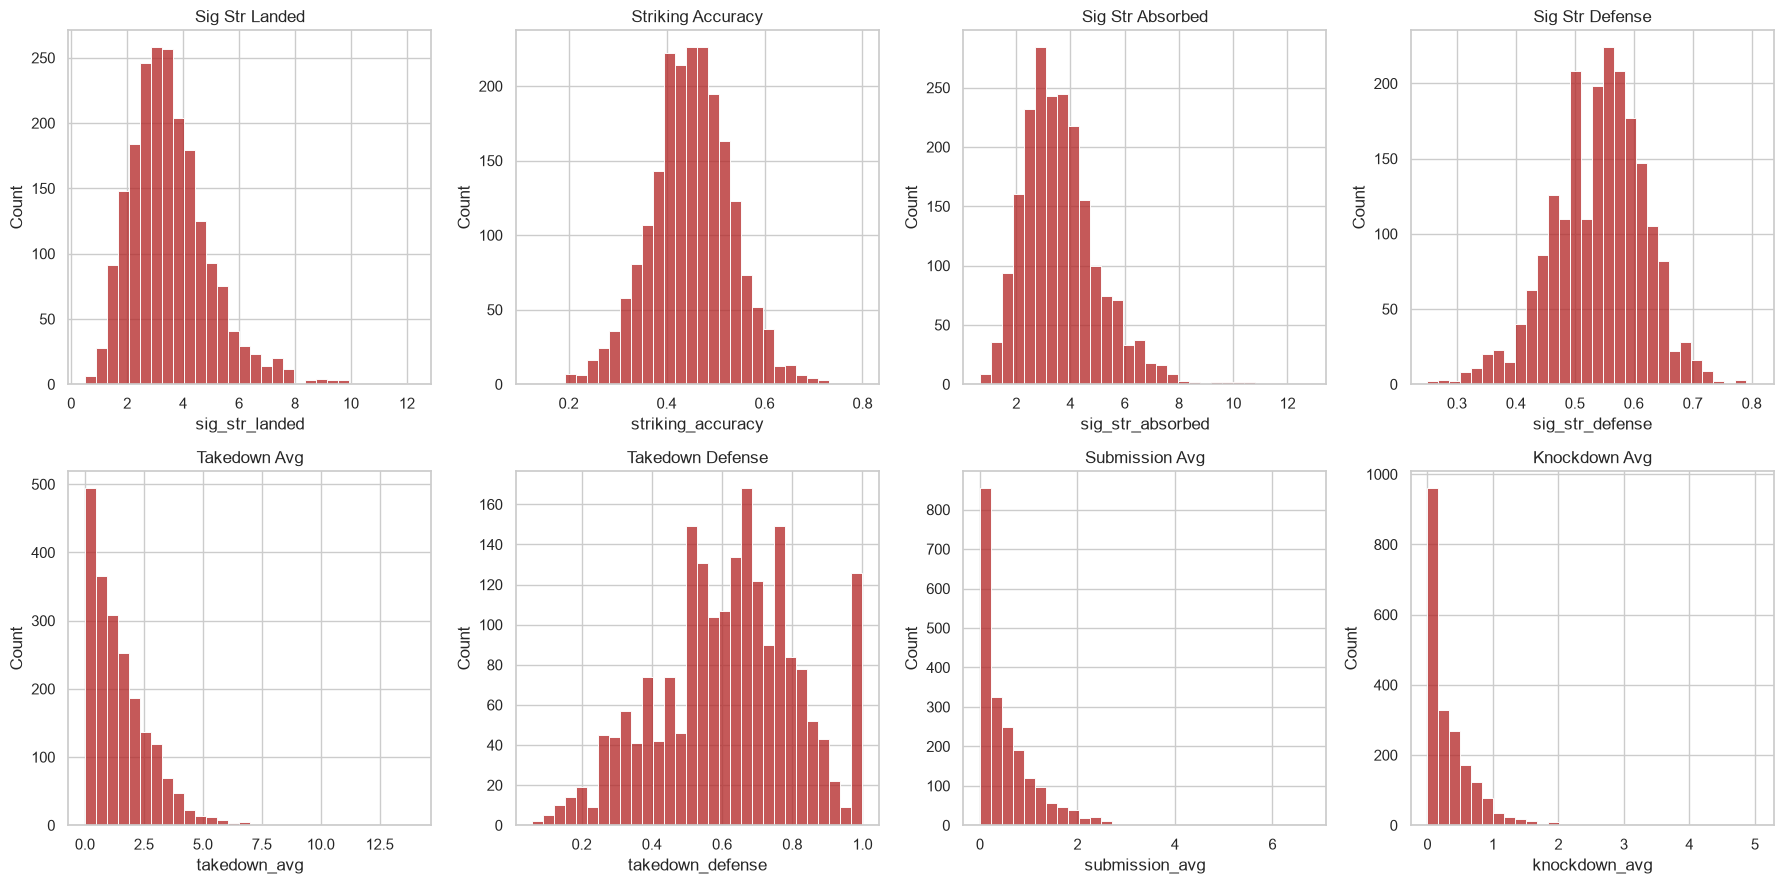

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for feature, axis in zip(model_features, axes):
    sns.histplot(
        fighter_df[feature],
        bins=30,
        ax=axis,
        color="firebrick"
    )
    axis.set_title(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

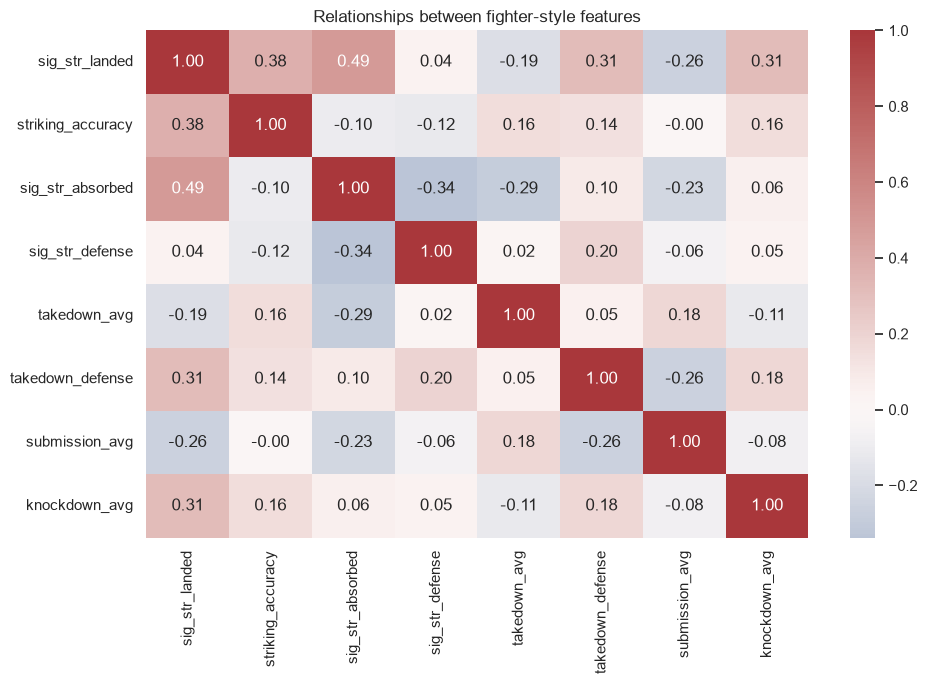

In [7]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    fighter_df[model_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title("Relationships between fighter-style features")
plt.tight_layout()
plt.show()

## Dataset and exploratory findings

- Fighters in the original dataset: **3,140 unique fighters**
- Fighters retained after filtering: **2,050**
- Minimum significant-strike attempts: **100**
- Retained proportion: **65.29%**
- Features containing the strongest outliers: **takedown activity, submission activity and knockdown production**
- Strongest positive correlation: **striking pace and strikes absorbed — 0.49**
- Strongest negative correlation: **strikes absorbed and striking defence — −0.34**

The combined experience, missing-value and duplicate-name filtering removed 1,090 unique fighters, or approximately 34.71% of the original fighter population. The remaining fighters had at least 100 recorded significant-strike attempts and complete values for all eight modelling features.

The striking variables were moderately right-skewed but concentrated around their middle ranges. Takedown activity, submission activity and knockdown production were much more strongly right-skewed and contained many values near zero. Their extreme maximum values were 14.00 takedowns, 6.77 submission attempts and 5.04 knockdowns per 15 minutes, compared with medians of 1.14, 0.345 and 0.20 respectively.

Striking pace and strikes absorbed had the strongest positive correlation at 0.49. This suggests that high-output fighters also tended to participate in higher-volume exchanges in which they absorbed more strikes.

Strikes absorbed and striking defence had the strongest negative correlation at −0.34, which is logically consistent because fighters who avoided a greater proportion of their opponents' strikes generally absorbed fewer strikes per minute.

Most other correlations were weak or moderate. Therefore, the features contained overlapping but non-identical information suitable for discovering multidimensional fighting styles.

## 2. Scaling the fighter statistics

The measurements use different units. For example, striking defence is a proportion, while significant strikes landed is a per-minute rate.

A quantile transformation converts every feature into a value between zero and one based approximately on the fighter's percentile position.

A value near:

- 0 indicates a relatively low value among eligible fighters;
- 0.5 indicates a middle-range value;
- 1 indicates a relatively high value.

This also prevents extreme statistical values from dominating the model.

All features remain non-negative, which is required by NMF.

In [8]:
scaler = QuantileTransformer(
    n_quantiles=min(100, len(fighter_df)),
    output_distribution="uniform",
    random_state=SEED
)

scaled_matrix = scaler.fit_transform(
    fighter_df[model_features]
)

scaled_df = pd.DataFrame(
    scaled_matrix,
    columns=model_features,
    index=fighter_df.index
)

scaled_df.describe().round(3)

,sig_str_landed,striking_accuracy,sig_str_absorbed,sig_str_defense,takedown_avg,takedown_defense,submission_avg,knockdown_avg
count,2050.000,2050.000,2050.000,2050.000,2050.000,2050.000,2050.000,2050.000
mean,0.500,0.500,0.500,0.500,0.491,0.502,0.450,0.424
std,0.289,0.289,0.289,0.289,0.302,0.291,0.347,0.366
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.248,0.248,0.253,0.273,0.249,0.268,0.000,0.000
50%,0.500,0.499,0.500,0.500,0.498,0.490,0.502,0.505
75%,0.749,0.751,0.750,0.737,0.749,0.737,0.749,0.747
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 3. Choosing the Number of Latent Styles

Non-negative Matrix Factorisation (NMF) approximates the fighter-feature matrix as:

$$
X \approx WH
$$

where:

X contains the scaled fighter statistics.
W describes each fighter’s mixture of latent fighting styles.
H describes the statistical characteristics associated with each style.

Several numbers of components are tested to determine an appropriate number of latent styles.

The models are evaluated using:

Reconstruction error: Measures how accurately the components reproduce the original feature matrix. Lower values are better.
Stability: Measures whether repeated model initialisations produce similar dominant-style assignments. Higher values are better.
Silhouette score: Measures how clearly fighters assigned to different dominant styles are separated in the feature space. Higher values are better.

Reconstruction error generally decreases as more components are added. Therefore, it should not be used alone to select the final number of styles. The final choice should balance reconstruction quality, assignment stability, group separation, and interpretability.

In [9]:
def evaluate_nmf(component_counts, repetitions=10):
    rows = []

    for components in component_counts:
        errors = []
        labels_runs = []
        models = []

        for run in range(repetitions):
            model = NMF(
                n_components=components,
                init="random",
                random_state=SEED + run,
                max_iter=5000
            )

            weights = model.fit_transform(scaled_matrix)
            profiles = model.components_

            component_scale = profiles.sum(axis=1)
            adjusted_weights = weights * component_scale
            dominant_labels = adjusted_weights.argmax(axis=1)

            errors.append(
                model.reconstruction_err_
                / np.linalg.norm(scaled_matrix)
            )

            labels_runs.append(dominant_labels)
            models.append(model)

        pair_scores = [
            adjusted_rand_score(labels_runs[i], labels_runs[j])
            for i, j in combinations(range(repetitions), 2)
        ]

        best_run = int(np.argmin(errors))
        best_labels = labels_runs[best_run]

        silhouette = (
            silhouette_score(scaled_matrix, best_labels)
            if len(np.unique(best_labels)) > 1
            else np.nan
        )

        group_sizes = np.bincount(
            best_labels,
            minlength=components
        )

        rows.append({
            "components": components,
            "normalised_error": np.mean(errors),
            "error_sd": np.std(errors),
            "stability_ARI": np.mean(pair_scores),
            "silhouette": silhouette,
            "smallest_group": group_sizes.min()
        })

    return pd.DataFrame(rows)

In [10]:
component_results = evaluate_nmf(
    component_counts=range(2, 9),
    repetitions=10
)

component_results.round(4)

,components,normalised_error,error_sd,stability_ARI,silhouette,smallest_group
0,2,0.4169,0.0000,0.9968,0.1506,625
1,3,0.3597,0.0000,0.9945,0.1028,269
2,4,0.2972,0.0000,0.9992,0.0871,95
3,5,0.2404,0.0001,0.8276,0.0693,90
4,6,0.1780,0.0000,0.9903,0.0398,34
5,7,0.1039,0.0000,0.9543,0.0214,35
6,8,0.0007,0.0001,0.8053,0.0352,194


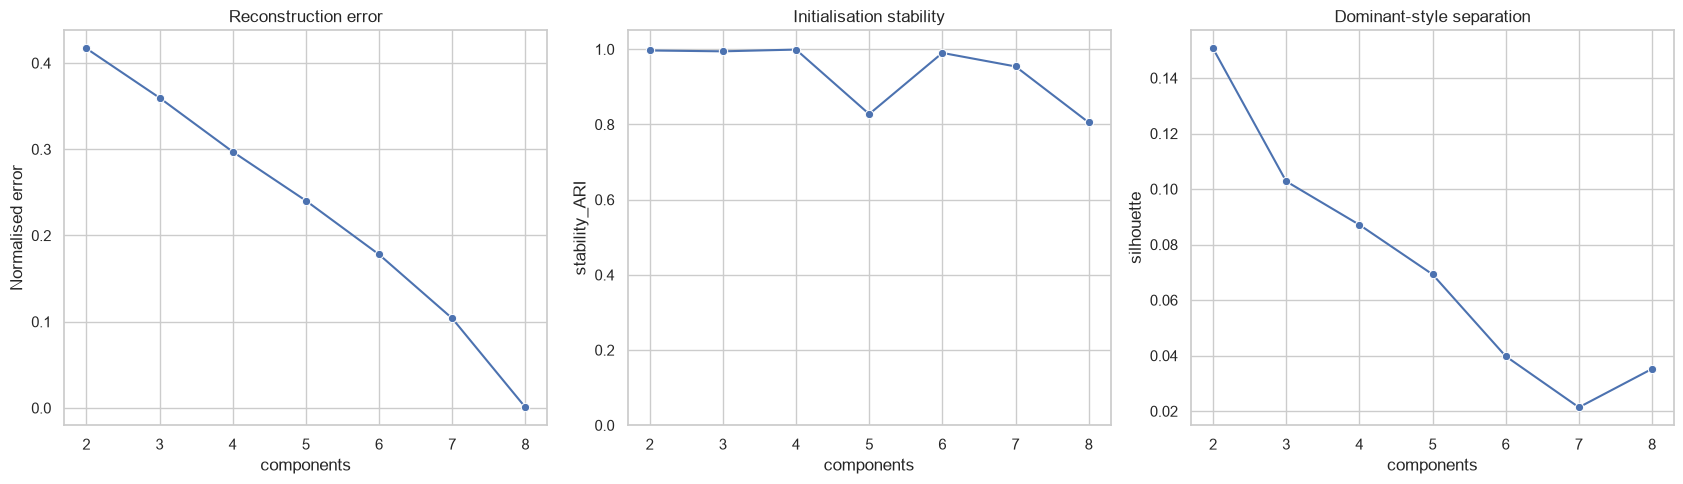

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.lineplot(
    data=component_results,
    x="components",
    y="normalised_error",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Reconstruction error")
axes[0].set_ylabel("Normalised error")

sns.lineplot(
    data=component_results,
    x="components",
    y="stability_ARI",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Initialisation stability")
axes[1].set_ylim(0, 1.05)

sns.lineplot(
    data=component_results,
    x="components",
    y="silhouette",
    marker="o",
    ax=axes[2]
)
axes[2].set_title("Dominant-style separation")

plt.tight_layout()
plt.show()

## Component selection

The evaluation compared models containing two to eight latent styles.

- Lowest reconstruction error: **8 components — 0.0007**
- Highest stability: **4 components — ARI 0.9992**
- Highest silhouette score: **2 components — 0.1506**
- Five-component reconstruction error: **0.2404**
- Five-component stability: **ARI 0.8276**
- Five-component silhouette score: **0.0693**
- Smallest group for the five-component solution: **90 fighters**

Reconstruction error decreased continuously as components were added, falling from 0.4169 with two components to 0.0007 with eight components. The near-zero error at eight components is not automatically evidence of a useful solution because the original data also contains eight features. At that point, NMF can approximately reproduce individual features instead of providing meaningful dimensional reduction.

The two-, three-, four-, six- and seven-component solutions were highly stable across random initialisations, with ARI values above 0.95. The five-component solution was less stable at 0.8276, although this still indicates substantial agreement rather than completely inconsistent results.

Silhouette scores were low for every solution and decreased from 0.1506 with two components to 0.0693 with five. This indicates that the data does not naturally divide into clearly separated fighter groups.

Five components were retained as a practical interpretability choice because they produced recognisable striking, grappling, defensive and accuracy-based dimensions while still reducing eight original features to five latent components. However, five was not the objectively strongest solution on stability or separation. The result should therefore be presented as an exploratory soft-archetype model rather than an optimal five-cluster solution.

In [12]:
N_COMPONENTS = 5

nmf = NMF(
    n_components=N_COMPONENTS,
    init="nndsvda",
    random_state=SEED,
    max_iter=5000
)

raw_weights = nmf.fit_transform(scaled_matrix)
raw_profiles = nmf.components_

In [13]:
component_scale = raw_profiles.sum(axis=1)

normalised_profiles = (
    raw_profiles / component_scale[:, None]
)

rescaled_weights = (
    raw_weights * component_scale[None, :]
)

style_mix_array = (
    rescaled_weights
    / rescaled_weights.sum(axis=1, keepdims=True)
)

style_names = [
    f"Style {number}"
    for number in range(1, N_COMPONENTS + 1)
]

style_mix_df = pd.DataFrame(
    style_mix_array,
    columns=style_names,
    index=fighter_df.index
)

profile_df = pd.DataFrame(
    normalised_profiles,
    index=style_names,
    columns=model_features
)

In [14]:
fighter_df["dominant_style"] = (
    style_mix_df.idxmax(axis=1)
)

fighter_df["style_strength"] = (
    style_mix_df.max(axis=1)
)

safe_mix = np.clip(style_mix_array, 1e-12, 1)

fighter_df["style_entropy"] = (
    -(safe_mix * np.log(safe_mix)).sum(axis=1)
    / np.log(N_COMPONENTS)
)

style_counts = (
    fighter_df["dominant_style"]
    .value_counts()
    .reindex(style_names, fill_value=0)
)

style_counts

dominant_style
Style 1     99
Style 2    634
Style 3    511
Style 4    479
Style 5    327
Name: count, dtype: int64

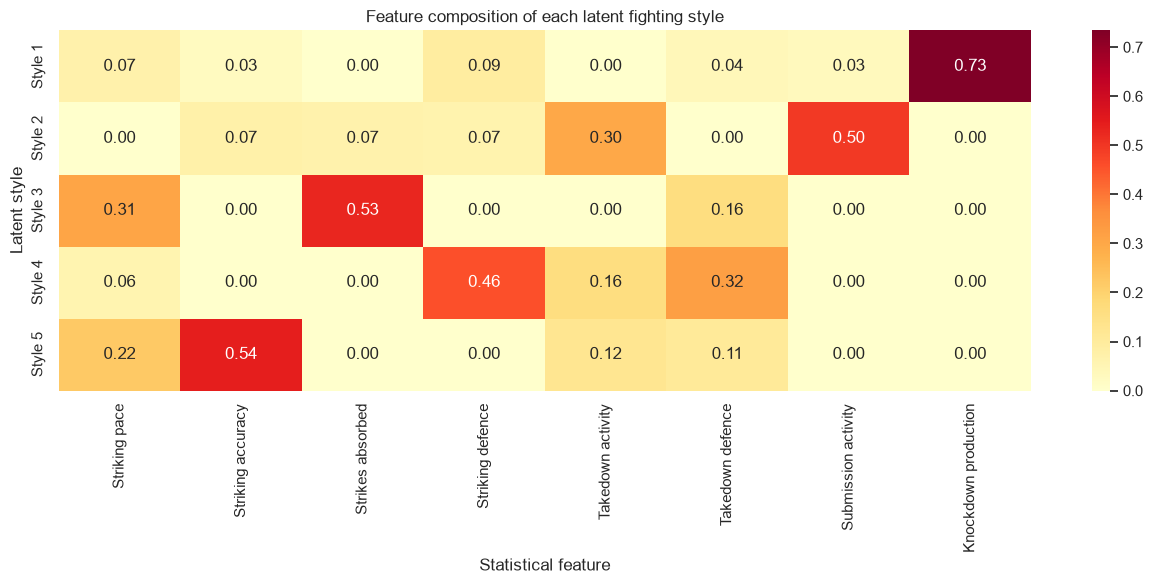

In [15]:
feature_labels = {
    "sig_str_landed": "Striking pace",
    "striking_accuracy": "Striking accuracy",
    "sig_str_absorbed": "Strikes absorbed",
    "sig_str_defense": "Striking defence",
    "takedown_avg": "Takedown activity",
    "takedown_defense": "Takedown defence",
    "submission_avg": "Submission activity",
    "knockdown_avg": "Knockdown production"
}

plt.figure(figsize=(13, 6))

sns.heatmap(
    profile_df.rename(columns=feature_labels),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Feature composition of each latent fighting style")
plt.xlabel("Statistical feature")
plt.ylabel("Latent style")
plt.tight_layout()
plt.show()

In [16]:
representative_rows = []

for style in style_names:
    top_indices = (
        style_mix_df[style]
        .nlargest(8)
        .index
    )

    for index in top_indices:
        representative_rows.append({
            "style": style,
            "fighter": fighter_df.loc[index, "name"],
            "weight_class": fighter_df.loc[index, "weight_class"],
            "style_weight": style_mix_df.loc[index, style],
            "dominant_strength": fighter_df.loc[index, "style_strength"],
            "style_entropy": fighter_df.loc[index, "style_entropy"]
        })

representatives_df = pd.DataFrame(representative_rows)

representatives_df.round(3)

,style,fighter,weight_class,style_weight,dominant_strength,style_entropy
0,Style 1,John Phillips,Middleweight,0.539,0.539,0.473
1,Style 1,Kai Asakura,Bantamweight,0.507,0.507,0.630
2,Style 1,Mehdi Baghdad,Lightweight,0.473,0.527,0.430
3,Style 1,Garrett Gross,Lightweight,0.462,0.462,0.640
4,Style 1,Shonie Carter,Welterweight,0.456,0.456,0.794
5,Style 1,Cain Carrizosa,Lightweight,0.435,0.456,0.620
6,Style 1,Justin McCully,Heavyweight,0.431,0.431,0.830
7,Style 1,Matt Dwyer,Welterweight,0.425,0.425,0.736
8,Style 2,Daiju Takase,Welterweight,0.950,0.950,0.131
9,Style 2,Daniel Roberts,Welterweight,0.890,0.890,0.236


In [17]:
context_features = [
    feature for feature in [
        "standing_pct",
        "clinch_percent",
        "ground_percent"
    ]
    if feature in fighter_df.columns
]

archetype_summary = (
    fighter_df
    .groupby("dominant_style")[model_features + context_features]
    .median()
    .reindex(style_names)
)

archetype_summary.round(3)

,sig_str_landed,striking_accuracy,sig_str_absorbed,sig_str_defense,takedown_avg,takedown_defense,submission_avg,knockdown_avg,standing_pct,clinch_percent,ground_percent
dominant_style,,,,,,,,,,,
Style 1,3.16,0.446,3.25,0.54,0.510,0.60,0.17,0.81,0.72,0.12,0.13
Style 2,2.62,0.442,3.05,0.53,1.835,0.50,1.02,0.13,0.65,0.14,0.17
Style 3,4.29,0.436,5.00,0.51,0.540,0.67,0.06,0.20,0.84,0.10,0.05
Style 4,3.13,0.424,2.91,0.62,1.430,0.74,0.17,0.17,0.76,0.11,0.10
Style 5,3.94,0.544,3.15,0.53,1.260,0.63,0.12,0.23,0.69,0.16,0.13


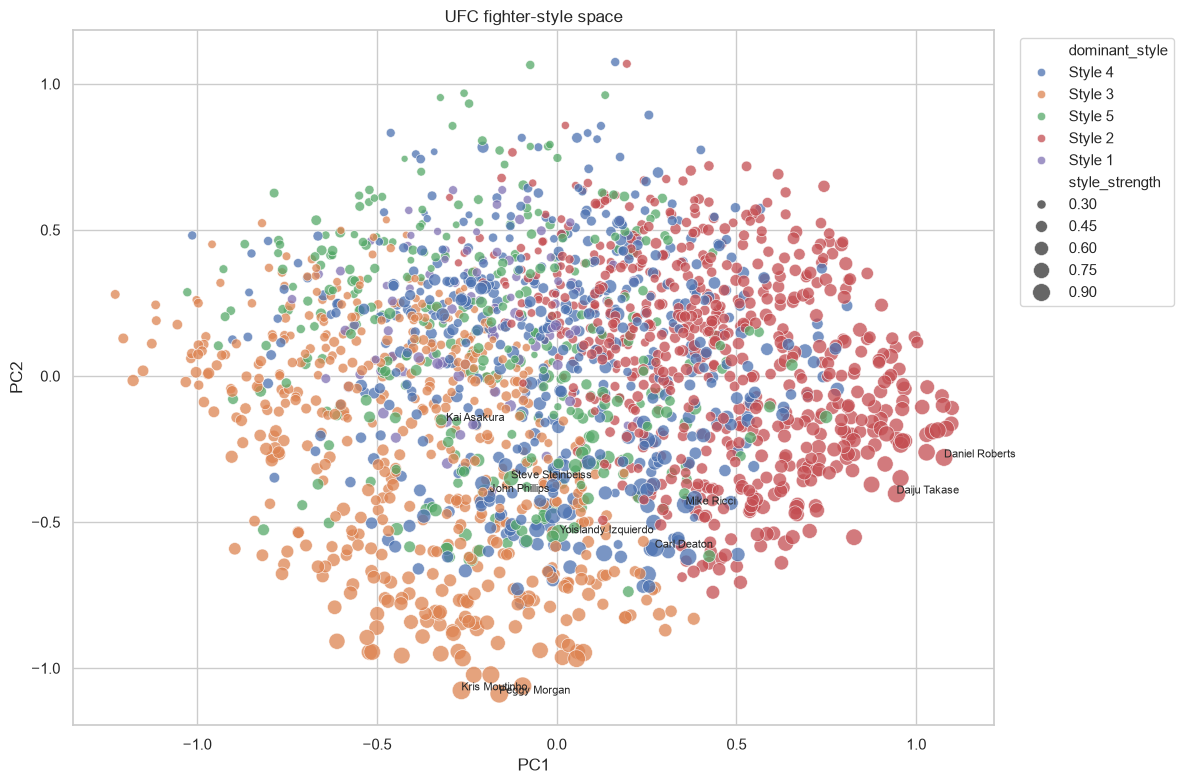

In [18]:
projection = PCA(
    n_components=2,
    random_state=SEED
).fit_transform(scaled_matrix)

plot_df = fighter_df[
    ["name", "dominant_style", "style_strength"]
].copy()

plot_df["PC1"] = projection[:, 0]
plot_df["PC2"] = projection[:, 1]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="dominant_style",
    size="style_strength",
    sizes=(25, 180),
    alpha=0.75
)

for style in style_names:
    label_indices = (
        plot_df.loc[
            plot_df["dominant_style"] == style,
            "style_strength"
        ]
        .nlargest(2)
        .index
    )

    for index in label_indices:
        row = plot_df.loc[index]
        plt.annotate(
            row["name"],
            (row["PC1"], row["PC2"]),
            fontsize=8
        )

plt.title("UFC fighter-style space")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Discovered fighter archetypes

### Style 1 — Knockdown-focused power attackers

Dominant feature: **knockdown production — 0.73**

Supporting features included striking defence at 0.09 and striking pace at 0.07, but knockdown production overwhelmingly defined this component.

Fighters with the highest Style 1 weights included **John Phillips, Kai Asakura and Mehdi Baghdad**.

The dominant Style 1 group had the highest median knockdown rate at 0.81 per 15 minutes. This component represents fighters whose statistical identity is strongly associated with producing knockdowns rather than high takedown or submission activity.

Style 1 contained only 99 dominant fighters, and even its strongest representatives generally had lower component weights than the strongest representatives of the other styles. It is therefore a relatively uncommon and less isolated component.

### Style 2 — Submission-oriented grapplers

Dominant features:

- **Submission activity — 0.50**
- **Takedown activity — 0.30**

Fighters with the highest Style 2 weights included **Daiju Takase, Daniel Roberts, Marcin Held, Genki Sudo and Rani Yahya**.

The dominant group had median values of 1.835 takedowns and 1.02 submission attempts per 15 minutes. It also had the highest median ground-striking proportion at 0.17 and the lowest median striking pace at 2.62 per minute.

This is the clearest grappling archetype. It represents fighters who use takedowns to create submission opportunities rather than relying primarily on standing striking.

### Style 3 — High-volume exchange strikers

Dominant features:

- **Strikes absorbed — 0.53**
- **Striking pace — 0.31**
- **Takedown defence — 0.16**

Fighters with the highest Style 3 weights included **Peggy Morgan, Kris Moutinho, James Mulheron and Anthony Christodoulou**.

This group produced the highest median striking pace at 4.29 significant strikes per minute but also absorbed the most at 5.00 per minute. Approximately 84% of its significant strikes were landed while standing, while median submission activity was only 0.06.

The component therefore represents high-volume, striking-oriented fighters involved in frequent exchanges. High strikes absorbed may indicate pressure fighting, defensive vulnerability or both, so this should not be labelled purely as an offensive strength.

### Style 4 — Defensive control fighters

Dominant features:

- **Striking defence — 0.46**
- **Takedown defence — 0.32**
- **Takedown activity — 0.16**

Fighters with the highest Style 4 weights included **Carl Deaton, Mike Ricci, Willamy Freire and Steve Lopez**.

This group had the highest median striking defence at 0.62 and takedown defence at 0.74. Its median takedown rate of 1.43 was also above the overall median.

The component represents fighters whose profile is built around limiting opponents' successful offence while retaining some wrestling activity. It is more defensive and control-oriented than submission-focused.

### Style 5 — Accurate and efficient strikers

Dominant features:

- **Striking accuracy — 0.54**
- **Striking pace — 0.22**
- **Takedown activity — 0.12**
- **Takedown defence — 0.11**

Fighters with the highest Style 5 weights included **Yoislandy Izquierdo, Steve Steinbeiss, Nandor Guelmino and Blood Diamond**.

This group achieved the highest median striking accuracy at 0.544 and the second-highest striking pace at 3.94 per minute. Unlike Style 3, strikes absorbed did not contribute meaningfully to the component.

Style 5 therefore represents efficient strikers who combine comparatively accurate striking with moderate wrestling characteristics.

### Distribution and overlap

The dominant-style group sizes were:

- Style 1: **99 fighters**
- Style 2: **634 fighters**
- Style 3: **511 fighters**
- Style 4: **479 fighters**
- Style 5: **327 fighters**

The average dominant-style strength was only 0.4083 and the median was 0.3809. Mean normalised entropy was high at 0.7877. These results indicate that most fighters were represented by mixtures of several components rather than one strongly dominant archetype.

The PCA plot also showed extensive overlap between the dominant-style colours. Therefore, the styles should be interpreted as recurring dimensions of fighting behaviour, not five completely separate categories.

## 4. Fighter similarity search

The similarity tool compares fighters using all eight transformed performance features.

For each candidate, it reports:

- Full-profile similarity based on the average feature distance.
- Archetype similarity based on the fighter's NMF style mixture.

A result near one indicates high statistical similarity. It does not mean that the fighters have identical techniques, tactics or competitive ability.

In [19]:
def find_fighters(search_text):
    matches = fighter_df.loc[
        fighter_df["name"].str.contains(
            search_text,
            case=False,
            na=False
        ),
        ["name", "weight_class", "dominant_style"]
    ]

    return matches.head(30)

find_fighters("Pereira")

,name,weight_class,dominant_style
1428,Viviane Pereira,Women's Strawweight,Style 3
1429,Alice Pereira,Women's Bantamweight,Style 4
1430,Alex Pereira,Heavyweight,Style 5
1431,Michel Pereira,Middleweight,Style 3


In [20]:
def resolve_fighter(fighter_name):
    exact = fighter_df.index[
        fighter_df["name"].str.casefold()
        == fighter_name.casefold()
    ].tolist()

    if len(exact) == 1:
        return exact[0]

    partial = fighter_df.index[
        fighter_df["name"].str.contains(
            fighter_name,
            case=False,
            na=False
        )
    ].tolist()

    if len(partial) == 0:
        raise ValueError(
            "Fighter not found or excluded during filtering."
        )

    if len(partial) > 1:
        names = fighter_df.loc[partial, "name"].tolist()
        raise ValueError(f"Multiple matches found: {names}")

    return partial[0]


def similar_fighters(
    fighter_name,
    number=10,
    same_weight_class=True
):
    fighter_index = resolve_fighter(fighter_name)
    fighter_class = fighter_df.loc[
        fighter_index,
        "weight_class"
    ]

    candidate_indices = fighter_df.index[
        fighter_df.index != fighter_index
    ].to_numpy()

    if same_weight_class:
        candidate_indices = fighter_df.index[
            (fighter_df.index != fighter_index)
            & (fighter_df["weight_class"] == fighter_class)
        ].to_numpy()

    feature_difference = (
        scaled_matrix[candidate_indices]
        - scaled_matrix[fighter_index]
    )

    rms_distance = np.sqrt(
        np.mean(feature_difference ** 2, axis=1)
    )

    full_profile_similarity = 1 - rms_distance

    selected_mix = style_mix_array[fighter_index]
    candidate_mix = style_mix_array[candidate_indices]

    archetype_similarity = (
        candidate_mix @ selected_mix
    ) / (
        np.linalg.norm(candidate_mix, axis=1)
        * np.linalg.norm(selected_mix)
    )

    results = fighter_df.loc[
        candidate_indices,
        [
            "name",
            "weight_class",
            "dominant_style",
            "style_strength"
        ]
    ].copy()

    results["profile_similarity"] = full_profile_similarity
    results["archetype_similarity"] = archetype_similarity

    return (
        results
        .sort_values("profile_similarity", ascending=False)
        .head(number)
        .reset_index(drop=True)
    )

In [21]:
TARGET_FIGHTER = "Max Holloway"

similar_fighters(
    TARGET_FIGHTER,
    number=10,
    same_weight_class=True
).round(3)

,name,weight_class,dominant_style,style_strength,profile_similarity,archetype_similarity
0,Edson Barboza,Lightweight,Style 3,0.317,0.845,0.981
1,Ignacio Bahamondes,Lightweight,Style 3,0.289,0.836,0.956
2,Sodiq Yusuff,Lightweight,Style 3,0.294,0.835,0.949
3,Esteban Ribovics,Lightweight,Style 3,0.387,0.830,0.956
4,Al Iaquinta,Lightweight,Style 3,0.296,0.816,0.949
5,Daniel Zellhuber,Lightweight,Style 3,0.425,0.811,0.938
6,Nasrat Haqparast,Lightweight,Style 3,0.340,0.807,0.972
7,Lando Vannata,Lightweight,Style 3,0.291,0.807,0.966
8,King Green,Lightweight,Style 5,0.267,0.805,0.950
9,John Makdessi,Lightweight,Style 4,0.316,0.803,0.966


## 5. Fighter matchup comparison

The comparison tool displays:

1. Each fighter's relative percentile-like position on the eight input features.
2. Each fighter's mixture of latent archetypes.

This can identify where two fighters have similar profiles and where their statistical styles contrast.

It is a scouting and exploratory tool, not a fight-outcome predictor.

In [22]:
def compare_fighters(fighter_a, fighter_b):
    index_a = resolve_fighter(fighter_a)
    index_b = resolve_fighter(fighter_b)

    indices = [index_a, index_b]
    names = fighter_df.loc[indices, "name"].tolist()

    percentile_profiles = pd.DataFrame(
        scaled_matrix[indices],
        index=names,
        columns=[
            feature_labels[feature]
            for feature in model_features
        ]
    )

    mixture_profiles = style_mix_df.loc[indices].copy()
    mixture_profiles.index = names

    raw_comparison = (
        fighter_df.loc[
            indices,
            ["name", "weight_class"] + model_features
        ]
        .set_index("name")
        .T
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.heatmap(
        percentile_profiles,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        ax=axes[0]
    )
    axes[0].set_title("Relative performance profiles")
    axes[0].set_xlabel("Feature")
    axes[0].set_ylabel("Fighter")

    mixture_profiles.T.plot(
        kind="bar",
        ax=axes[1]
    )
    axes[1].set_title("Latent-style mixture")
    axes[1].set_xlabel("Style")
    axes[1].set_ylabel("Proportion")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    return raw_comparison

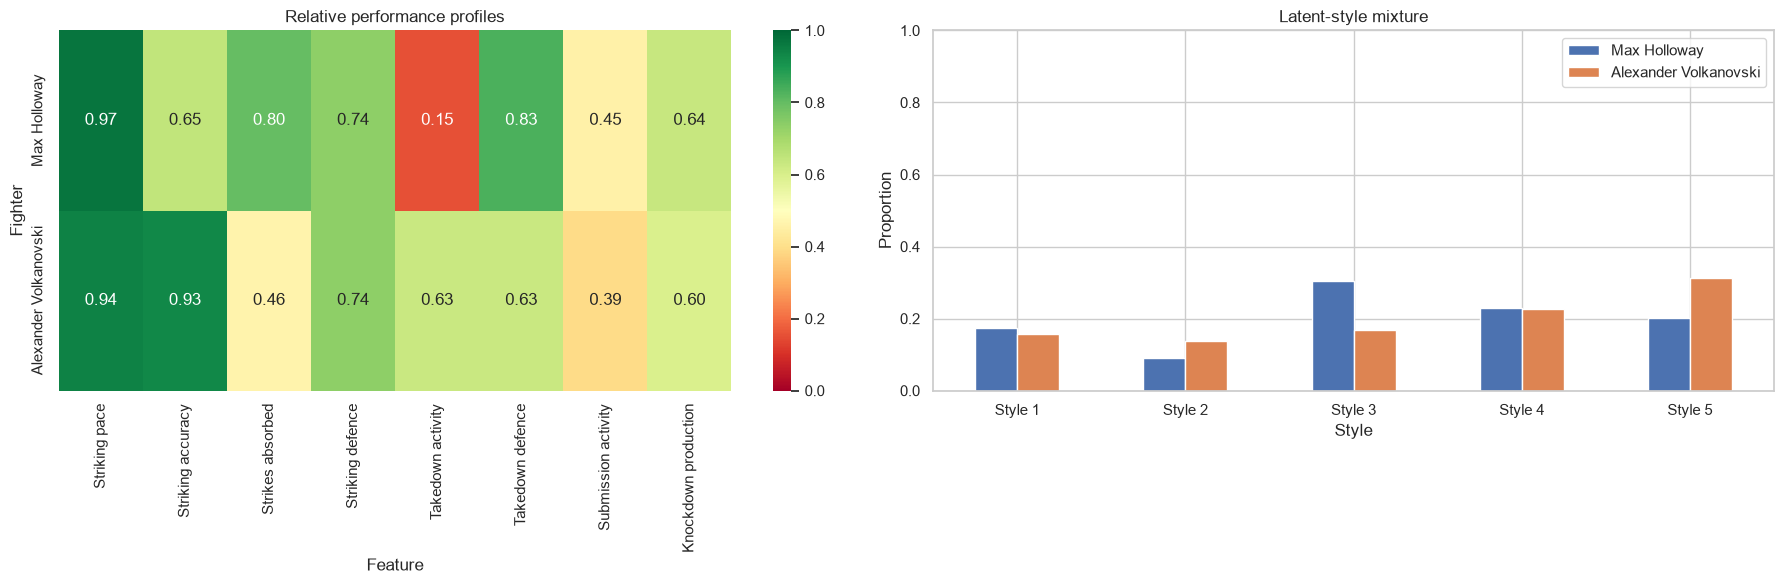

name,Max Holloway,Alexander Volkanovski
weight_class,Lightweight,Featherweight
sig_str_landed,6.91,5.99
striking_accuracy,0.481365,0.571114
sig_str_absorbed,4.61,3.31
sig_str_defense,0.59,0.59
takedown_avg,0.23,1.63
takedown_defense,0.81,0.69
submission_avg,0.28,0.2
knockdown_avg,0.34,0.3


In [23]:
FIGHTER_A = "Max Holloway"
FIGHTER_B = "Alexander Volkanovski"

compare_fighters(
    FIGHTER_A,
    FIGHTER_B
).round(3)

## Fighter scouting interpretation

### Similar-fighter search

Target fighter: **Max Holloway**

The closest same-weight-class statistical comparisons were:

1. **Edson Barboza — profile similarity 0.845; archetype similarity 0.981**
2. **Ignacio Bahamondes — profile similarity 0.836; archetype similarity 0.956**
3. **Sodiq Yusuff — profile similarity 0.835; archetype similarity 0.949**

Other relatively close comparisons included Esteban Ribovics, Al Iaquinta, Daniel Zellhuber, Nasrat Haqparast and Lando Vannata.

The closest fighters generally shared a striking-oriented profile involving high striking activity, relatively low takedown activity and substantial contributions from the high-volume exchange component.

The similarities were not exact. Holloway had an exceptionally high striking-pace percentile of 0.97. Barboza had a lower pace but greater knockdown production, while Bahamondes had greater submission and knockdown activity. Sodiq Yusuff had lower striking and takedown-defence values.

The very high archetype similarities show that these fighters used comparable mixtures of broad components, while the lower full-profile similarities reveal meaningful differences within those mixtures.

### Matchup comparison

Fighter A: **Max Holloway**

Fighter B: **Alexander Volkanovski**

#### Raw statistical comparison

| Feature | Max Holloway | Alexander Volkanovski |
|---|---:|---:|
| Significant strikes landed per minute | 6.91 | 5.99 |
| Striking accuracy | 0.481 | 0.571 |
| Significant strikes absorbed per minute | 4.61 | 3.31 |
| Striking defence | 0.59 | 0.59 |
| Takedowns per 15 minutes | 0.23 | 1.63 |
| Takedown defence | 0.81 | 0.69 |
| Submissions per 15 minutes | 0.28 | 0.20 |
| Knockdowns per 15 minutes | 0.34 | 0.30 |

Holloway had higher striking output, takedown defence, submission activity and slightly higher knockdown production. However, he also absorbed considerably more strikes.

Volkanovski had substantially higher striking accuracy and takedown activity. He landed approximately 57.1% of his significant-strike attempts compared with Holloway's 48.1%, while averaging 1.63 takedowns compared with Holloway's 0.23.

Both fighters had the same recorded striking-defence rate of 0.59. They also shared very high striking-pace percentiles and similar knockdown and submission production.

Holloway's largest archetype contribution was Style 3, the high-volume exchange style, at approximately 30.5%. Volkanovski's largest contribution was Style 5, the accurate and efficient striking style, at approximately 31.2%. Both had similar Style 4 defensive-control contributions of approximately 23%.

The comparison therefore describes Holloway as the more volume-oriented and exchange-heavy striker, while Volkanovski combined accurate striking with substantially greater takedown activity. This identifies a meaningful stylistic contrast but does not predict which fighter would win.

In [24]:
final_labels = fighter_df["dominant_style"].map(
    {style: index for index, style in enumerate(style_names)}
)

final_error = (
    nmf.reconstruction_err_
    / np.linalg.norm(scaled_matrix)
)

final_silhouette = silhouette_score(
    scaled_matrix,
    final_labels
)

final_summary = pd.Series({
    "eligible_fighters": len(fighter_df),
    "latent_styles": N_COMPONENTS,
    "normalised_reconstruction_error": final_error,
    "dominant_style_silhouette": final_silhouette,
    "mean_style_strength": fighter_df["style_strength"].mean(),
    "median_style_strength": fighter_df["style_strength"].median(),
    "mean_style_entropy": fighter_df["style_entropy"].mean()
})

final_summary.round(4)

eligible_fighters                  2050.0000
latent_styles                         5.0000
normalised_reconstruction_error       0.2403
dominant_style_silhouette             0.0706
mean_style_strength                   0.4083
median_style_strength                 0.3809
mean_style_entropy                    0.7877
dtype: float64

## Final interpretation

### Model quality

- Eligible fighters: **2,050**
- Latent styles: **5**
- Normalised reconstruction error: **0.2403**
- Dominant-style silhouette score: **0.0706**
- Mean dominant-style strength: **0.4083**
- Median dominant-style strength: **0.3809**
- Mean style entropy: **0.7877**
- Five-component stability ARI: **0.8276**

The normalised reconstruction error indicates that the residual error had approximately 24.03% of the original matrix's magnitude. The five-component representation therefore retained considerable information while reducing the eight original features to five latent dimensions.

The silhouette score of 0.0706 indicates very weak separation between dominant-style groups. This is also visible in the PCA projection, where the five colours overlap extensively. The fighters do not form five naturally isolated populations.

The stability ARI of 0.8276 indicates substantial agreement across random initialisations, although the five-component model was less stable than the four- and six-component alternatives. Some fighters near component boundaries may therefore change dominant assignments across model runs.

The mean dominant strength of 0.4083 and high mean entropy of 0.7877 confirm that the components work better as overlapping style dimensions than as exclusive cluster labels.

### Main findings

NMF discovered five interpretable statistical archetypes:

1. Knockdown-focused power attackers.
2. Submission-oriented grapplers.
3. High-volume exchange strikers.
4. Defensive control fighters.
5. Accurate and efficient strikers.

These archetypes describe recurring statistical patterns rather than complete fighter identities. Most fighters combined several of the components, which reflects the multidimensional nature of MMA.

The similarity system identified fighters with comparable eight-feature profiles and separately measured similarity between their NMF mixtures. The Max Holloway example returned several plausible striking-oriented comparisons while still revealing meaningful differences in pace, defence, submissions and knockdowns.

The Holloway–Volkanovski comparison also demonstrated the practical value of the system. It separated Holloway's high-volume exchange profile from Volkanovski's more accurate and takedown-active profile without incorrectly converting those differences into a winner prediction.

### Practical value

The project could support:

- opponent-profile exploration;
- identifying statistically comparable fighters;
- finding training partners with similar measurable tendencies;
- analysing potential replacement opponents;
- communicating stylistic differences using data;
- comparing fighter profiles across divisions.

The results should complement fight footage and expert analysis rather than replace them.

### Limitations

The model describes aggregated recorded behaviour, not complete MMA technique.

Important limitations include:

- career statistics combine performances from different periods and opponents;
- the current listed weight class may differ from the division in which earlier statistics were produced;
- fighter ability and style can change over time;
- striking statistics do not fully describe footwork, timing, feints or tactical decisions;
- defence statistics depend partly on opponent quality;
- the model does not include control time, strike targets or position-specific grappling;
- the 100-attempt threshold improves reliability but does not make every fighter equally well observed;
- the five-component choice was interpretability-driven rather than clearly optimal according to the quantitative diagnostics.

The archetypes, dominant assignments and similarity scores should therefore be treated as exploratory scouting evidence rather than objective style labels or predictions of fight outcomes.